### What are the proportions of dem and rep in the house of rep among presidential swing states?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [19]:
df_house = pd.read_csv("data/house_candidate.csv")

house

,district,candidate,party,total_votes,won
0,Delaware at large,Lisa Blunt Rochester,DEM,281382,True
1,Delaware at large,Lee Murphy,REP,196392,False
2,Delaware at large,Catherine Purcell,IND,6682,False
3,Delaware at large,David Rogers,LIB,3814,False
4,Florida’s 1st district,Matt Gaetz,REP,283352,True
...,...,...,...,...,...
1210,California’s 21st district,TJ Cox,DEM,84406,False
1211,California’s 25th district,Mike Garcia,REP,169638,True
1212,California’s 25th district,Christy Smith,DEM,169305,False
1213,California’s 39th district,Young Kim,REP,173946,True


In [31]:
states_list = [
"Alabama", "Alaska", "Arizona", "Arkansas", "California",
"Colorado", "Connecticut", "Delaware", "Florida", "Georgia",
"Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
"Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
"Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri",
"Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
"New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
"Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina",
"South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
"West Virginia", "Washington", "Virginia", "Wisconsin", "Wyoming"
]
States = []

for district in df_house["district"]:
    for index in range(len(states_list)):
        if states_list[index] in district:
            States.append(states_list[index])
            break
    else:
        States.append("None")

df_house["States"] = States






house_winners_agg = df_house.query("won == True")
display(house_winners_agg)
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in house_winners_agg.groupby("States"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for party in state_data["party"]: #loops through "total_votes" and "party" for each state
        total = total + 1 #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + 1
        elif party == "REP":
            rep = rep + 1
        else:
            ind = ind + 1
            
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    elif prop_reps == prop_dems and prop_reps > prop_inds:
        win = "TIE"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
house_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "House_Majority": winner})

display(house_proportions)

,district,candidate,party,total_votes,won,States
0,Delaware at large,Lisa Blunt Rochester,DEM,281382,True,Delaware
4,Florida’s 1st district,Matt Gaetz,REP,283352,True,Florida
7,Florida’s 2nd district,Neal Dunn,REP,305337,True,Florida
9,Florida’s 3rd district,Kat Cammack,REP,223075,True,Florida
11,Florida’s 4th district,John Rutherford,REP,308497,True,Florida
...,...,...,...,...,...,...
1203,Connecticut’s 5th district,Jahana Hayes,DEM,192484,True,Connecticut
1206,United States’s 0th district,The Democratic candidate,DEM,77138263,True,None
1209,California’s 21st district,David Valadao,REP,85928,True,California
1211,California’s 25th district,Mike Garcia,REP,169638,True,California


,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,House_Majority
0,Alabama,0.142857,0.857143,0.0,REP
1,Alaska,0.000000,1.000000,0.0,REP
2,Arizona,0.555556,0.444444,0.0,DEM
3,Arkansas,0.000000,1.000000,0.0,REP
4,California,0.792453,0.207547,0.0,DEM
5,Colorado,0.571429,0.428571,0.0,DEM
6,Connecticut,1.000000,0.000000,0.0,DEM
7,Delaware,1.000000,0.000000,0.0,DEM
8,Florida,0.407407,0.592593,0.0,REP
9,Georgia,0.428571,0.571429,0.0,REP


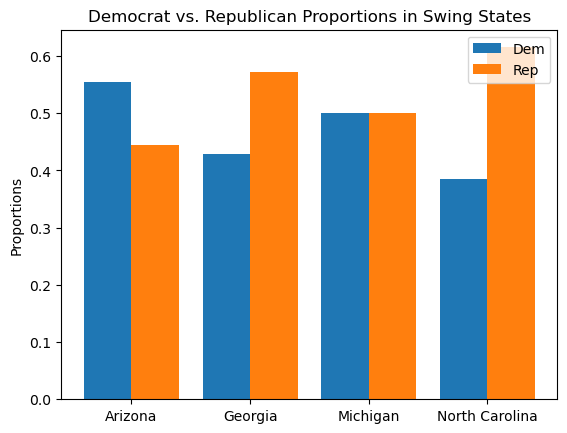

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,House_Majority
2,Arizona,0.555556,0.444444,0.0,DEM
9,Georgia,0.428571,0.571429,0.0,REP
21,Michigan,0.500000,0.500000,0.0,TIE
33,North Carolina,0.384615,0.615385,0.0,REP


In [32]:
cats = ['Arizona', 'Georgia', 'Michigan', 'North Carolina']

house = house_proportions.query("State in @cats")

house_list = house["State"].tolist()

v1, v2 = house["Proportion_Democrat"], house["Proportion_Republican"]
w, x = 0.4, np.arange(len(house_list))

plt.bar(x - w/2, v1, w, label='Dem')
plt.bar(x + w/2, v2, w, label='Rep')

plt.xticks(x, house_list)
plt.ylabel('Proportions')
plt.title('Democrat vs. Republican Proportions in Swing States')
plt.legend()
plt.show()
display(house)

In [33]:
house_proportions.to_csv("data/house_proportions.csv", index = False)